In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter

In [2]:
df = pd.read_parquet(r"C:\Users\Mateus Monteleone\Projects\ic\data\tweets_base.parquet")

In [3]:
da = df

In [4]:
da.head()

,full_text,clean_text
0,se o lula ganhar eu quero uma roda de beijo co...,se o lula ganhar eu quero uma roda de beijo co...
1,@ixslorena LULA PRESIDENTE HOJE,@USER LULA PRESIDENTE HOJE
2,mãe morrendo de alegria na carreata do Lula,mãe morrendo de alegria na carreata do Lula
3,@trajaza AVISA QUE MEU PAI LULA VAI GANHAR PRI...,@USER AVISA QUE MEU PAI LULA VAI GANHAR PRIMEI...
4,@indieoffw O RJ elegendo castro e juram que va...,@USER O RJ elegendo castro e juram que vai dar...


In [5]:
def analise_termos_economicos_expandida(df):

    palavras_chave_economicas = [
        'emprego', 'desemprego', 'bolsa', 'inflação', 'renda', 'dolar',
        'industria', 'salário', 'valor', 'auxílio', 'banco', 'credito',
        'desigual', 'empreendedor', 'financeiro', 'dólar',
        'desigualdade', 'educação', 'finanças', 'financiamento',
        'impostos', 'imposto', 'economia', 'igualdade'
    ]

    padrao_economico = re.compile(
        r'\b(' + '|'.join(map(re.escape, palavras_chave_economicas)) + r')\b',
        flags=re.IGNORECASE
    )

    mask_economico = df["clean_text"].str.contains(padrao_economico, na=False)
    df_economico = df.loc[mask_economico].copy()

    contador = Counter()

    for texto in df_economico["clean_text"]:
        encontrados = set(padrao_economico.findall(texto.lower()))
        contador.update(encontrados)

    contagens_df = (
        pd.Series(contador)
        .sort_values(ascending=False)
    )

    contagens_df.plot(kind="bar", figsize=(12,6))
    plt.title("Frequência de termos econômicos")
    plt.ylabel("Número de tweets")
    plt.tight_layout()
    plt.show()

    return df_economico


C:\Users\Mateus Monteleone\AppData\Local\Temp\ipykernel_416\1309831646.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_economico = df["clean_text"].str.contains(padrao_economico, na=False)


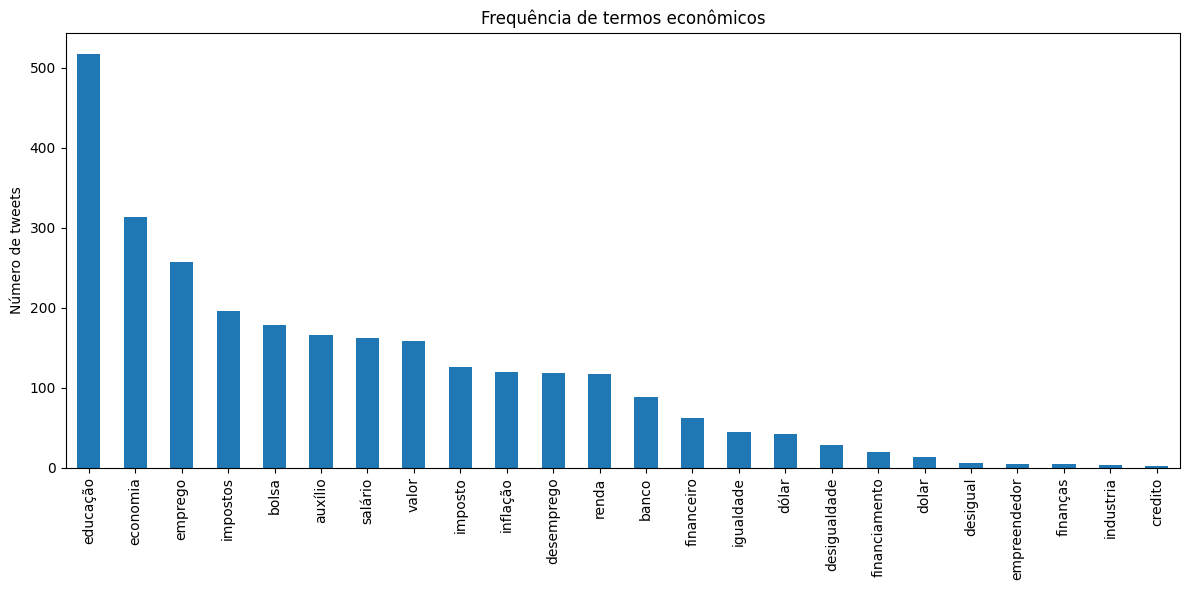

In [16]:
df_economico = analise_termos_economicos_expandida(da)

In [17]:
df_economico.head()

,full_text,clean_text
40,@jairbolsonaro ele vai dançar tão mal mas elev...,@USER ele vai dançar tão mal mas elevou o país...
110,@JornalOGlobo Maior furada essas pesquisas a G...,@USER Maior furada essas pesquisas a Globo anu...
111,@CentralEleicoes 1 DIA PRO 13 Por mais educaçã...,"@USER 1 DIA PRO 13 Por mais educação , saúde ,..."
123,Bolsonaro tenha de todas as formas atingir o e...,Bolsonaro tenha de todas as formas atingir o e...
163,@Joseniakk @jairbolsonaro @filgmartin Neymar. ...,@USER @USER @USER Neymar . Anistia federal de ...


In [18]:
len(df_economico)

2472

In [ ]:
df_economico.to_parquet(
    "tweets_economicos.parquet",
    index=False
)

In [ ]:
df_nao_economico = df.loc[~df.index.isin(df_economico.index)]

In [11]:
df_nao_economico.head()

,full_text,clean_text
0,se o lula ganhar eu quero uma roda de beijo co...,se o lula ganhar eu quero uma roda de beijo co...
1,@ixslorena LULA PRESIDENTE HOJE,@USER LULA PRESIDENTE HOJE
2,mãe morrendo de alegria na carreata do Lula,mãe morrendo de alegria na carreata do Lula
3,@trajaza AVISA QUE MEU PAI LULA VAI GANHAR PRI...,@USER AVISA QUE MEU PAI LULA VAI GANHAR PRIMEI...
4,@indieoffw O RJ elegendo castro e juram que va...,@USER O RJ elegendo castro e juram que vai dar...


In [15]:
df_nao_economico.to_parquet(
    "tweets_nao_economicos.parquet",
    index=False
)

In [28]:
len(df_economico) + len(df_nao_economico)

192954

In [19]:
sample_econ = df_economico.sample(200, random_state=42)
sample_nao = df_nao_economico.sample(200, random_state=42)

In [20]:
sample_econ = sample_econ.copy()
sample_econ["is_economic"] = 1

sample_nao = sample_nao.copy()
sample_nao["is_economic"] = 0

In [21]:
df_manual = pd.concat([sample_econ, sample_nao], ignore_index=True)

In [25]:
df_manual["sentiment_manual"] = None


In [27]:
df_manual.head()

,full_text,clean_text,is_economic,sentiment_manual
0,Única coisa que o bozó pode fazer é liberar um...,Única coisa que o bozó pode fazer é liberar um...,1,None
1,@LulaOficial @fbbreal Lula perde e Fátima perd...,@USER @USER Lula perde e Fátima perderá o empr...,1,None
2,Bolsonaro colocou o pobre no lixo o valor só p...,Bolsonaro colocou o pobre no lixo o valor só p...,1,None
3,Fiz questão de assinar a Carta Compromisso pel...,Fiz questão de assinar a Carta Compromisso pel...,1,None
4,"@paulonbjr Brincou, né? Só tem essa nas mãos d...","@USER Brincou , né ? Só tem essa nas mãos de q...",1,None


In [26]:
df_manual.to_parquet(
    "df_rotulação_manual.parquet",
    index=False
)